<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Projet: Student Performance....
<a class="anchor" id="1"></a> 

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

In [121]:
import warnings
warnings.filterwarnings("ignore")

In [122]:
df=pd.read_csv("../data/StudentsPerformance.csv")

***

![](../../imgs/featureEngin.png)

In [123]:
df.shape

(1000, 8)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   Group                        1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


<a id = "5" ></a>
Let's take a look at our data
<a id = "dflook" ></a>

In [125]:
df

,gender,Group,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [126]:
for col in df.select_dtypes(exclude="number").columns:
    print(f" {col:-<30} {df[col].unique()}")

 gender------------------------ ['female' 'male']
 Group------------------------- ['group B' 'group C' 'group A' 'group D' 'group E']
 parental level of education--- ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
 lunch------------------------- ['standard' 'free/reduced']
 test preparation course------- ['none' 'completed']


<a id = "6" ></a>
<h2 style="text-align:center;">Attribute Information</h2>
   <table style="width:100%">
     <tr>
       <th>Column Name</th>
       <th>Description</th>
    </tr>
    <tr>
       <td>gender</td>
       <td>Male/ Female</td>
    </tr>
     <tr>
    <td>race/ethnicity</td>
    <td>Group division from A to E</td>
  </tr>
  <tr>
    <td>parental level of education</td>
    <td>Details of parental education varying from high school to master's degree </td>
  </tr>
    <tr>
    <td>lunch</td>
    <td>Type of lunch selected</td>
  </tr>
    <tr>
    <td>test preparation course</td>
    <td>Course details</td>
  </tr>
    <tr>
    <td>math score</td>
    <td>Marks secured by a student in Mathematics</td>
  </tr>
    <tr>
    <td>reading score</td>
    <td>Marks secured by a student in Reading</td>
  </tr>
    <tr>
    <td>writing score</td>
    <td>Marks secured by a student in Writing</td>
  </tr>
</table>
<a id = "attribute" ></a>

***

In [127]:
# missing values 
df.isna().sum()

gender                         0
Group                          0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [128]:
#initializing the passmarks
passmark=35

In [129]:
# create a Percentage Feature in function of  Math , reading an writing  scores  
df['Percentage'] = (df['math score']+df['reading score']+df['writing score'])/3

<a id = "10" ></a>
<center> <span style="font-family:serif; font-size:24px;"> Grading System </span> </center>

| Percentage Range | Grade | Qualification |
| --- | --- | --- |
| >= 95 | O | Outstanding |
| >= 81 | A | Very Good |
| >= 71 | B | Good |
| >= 61 | C | Average |
| >= 51 | D | Sufficient |
| >= 41 | E | Passable |
| < 41 | F | Fail |

<a id = "10" ></a>

In [130]:

import pandas as pd

# Define the bins and corresponding labels
bins = [0, 40, 50, 60, 70, 80, 95, 100]  # Boundaries for the grades
labels = ['F', 'E', 'D', 'C', 'B', 'A', 'O']  # Corresponding grade labels

# Apply pd.cut to create the 'grade' column
df["grade"] = pd.cut(df["Percentage"], bins=bins, labels=labels, include_lowest=True)

In [131]:
df.head(10)

,gender,Group,parental level of education,lunch,test preparation course,math score,reading score,writing score,Percentage,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,B
1,female,group C,some college,standard,completed,69,90,88,82.333333,A
2,female,group B,master's degree,standard,none,90,95,93,92.666667,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,E
4,male,group C,some college,standard,none,76,78,75,76.333333,B
5,female,group B,associate's degree,standard,none,71,83,78,77.333333,B
6,female,group B,some college,standard,completed,88,95,92,91.666667,A
7,male,group B,some college,free/reduced,none,40,43,39,40.666667,E
8,male,group D,high school,free/reduced,completed,64,64,67,65.000000,C
9,female,group B,high school,free/reduced,none,38,60,50,49.333333,E


In [132]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089000,15.163080,0.0,57.000000,66.000000,77.000000,100.0
reading score,1000.0,69.169000,14.600192,17.0,59.000000,70.000000,79.000000,100.0
writing score,1000.0,68.054000,15.195657,10.0,57.750000,69.000000,79.000000,100.0
Percentage,1000.0,67.770667,14.257326,9.0,58.333333,68.333333,77.666667,100.0


***

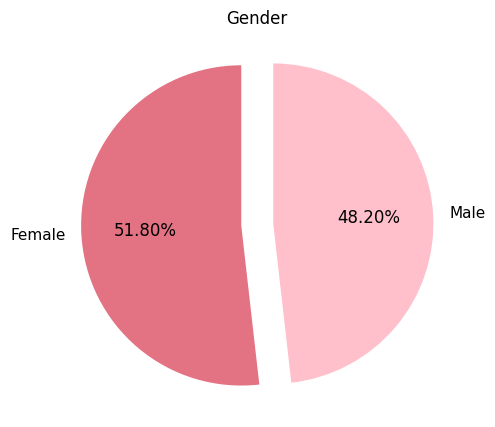

In [133]:
plt.figure(figsize=(5, 5))
labels=['Female', 'Male']
plt.pie(df['gender'].value_counts(),labels=labels,explode=[0.1,0.1],
        autopct='%1.2f%%',colors=['#E37383','#FFC0CB'], startangle=90)
plt.title('Gender')
plt.axis('equal')
plt.show()

* Out of the total number of students, 51.89% are females while 48.20% are males.
 

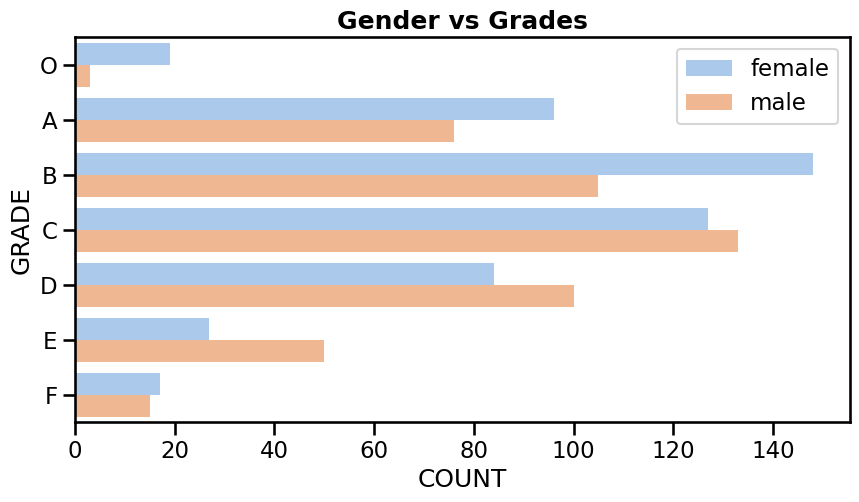

In [134]:
plt.figure(figsize=(10,5))
sns.set_context("talk",font_scale=1)
sns.set_palette("pastel")
ax = sns.countplot(y="grade", hue="gender", data=df, order=["O","A","B","C","D","E","F"])
ax.legend(loc='upper right',frameon=True)
plt.title('Gender vs Grades', fontsize=18, fontweight='bold')
ax.set(xlabel='COUNT',ylabel='GRADE')
plt.show()

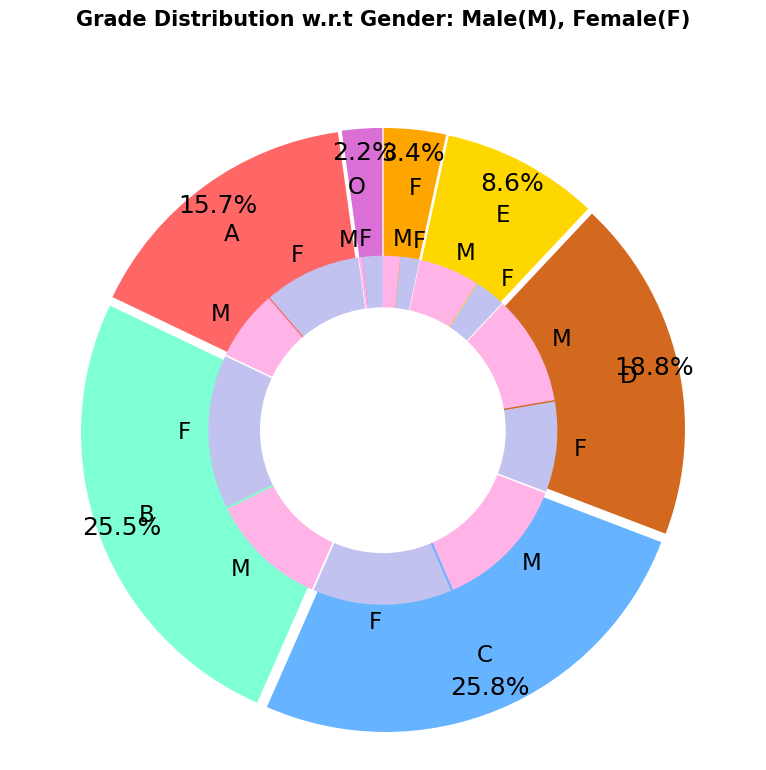

In [135]:
plt.figure(figsize=(8, 8))
labels =["O","A","B","C","D","E","F"]
values = [22,157,255,258,188,86,34]
labels_gender = ["F","M","F","M","F","M","F","M","F","M","F","M","F","M"]
sizes_gender = [19,3,91,66,145,110,131,127,85,103,29,57,18,16]
colors = ['orchid', '#ff6666', 'aquamarine', '#66b3ff','chocolate','gold','orange']
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6']
explode = (0.3,0.3,0.3,0.3,0.3,0.3,0.3) 
explode_gender = (0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1)
#Plot
plt.pie(values, labels=labels,autopct='%1.1f%%' ,pctdistance=0.92, labeldistance=0.80,colors=colors, startangle=90,frame=True, explode=explode,radius=12)
plt.pie(sizes_gender,labels=labels_gender,colors=colors_gender,startangle=90, explode=explode_gender,radius=7)
#Draw circle
centre_circle = plt.Circle((0,0),5,color='black', fc='white',linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Grade Distribution w.r.t Gender: Male(M), Female(F)', fontsize=15, fontweight='bold',y=1.1)

# show plot 
 
plt.axis('equal')
plt.tight_layout()
plt.show()

From the above visualization we infer:
* The majority of students who earned an O grade were female.
* Majority of students received B grade followed by C.
* More female students received A and B Grade relative to male students.
* More number of boys received D and E grade.
* Almost similar number of both, male and female, got F grade.

In [136]:
df.select_dtypes(include="number").columns

Index(['math score', 'reading score', 'writing score', 'Percentage'], dtype='object')

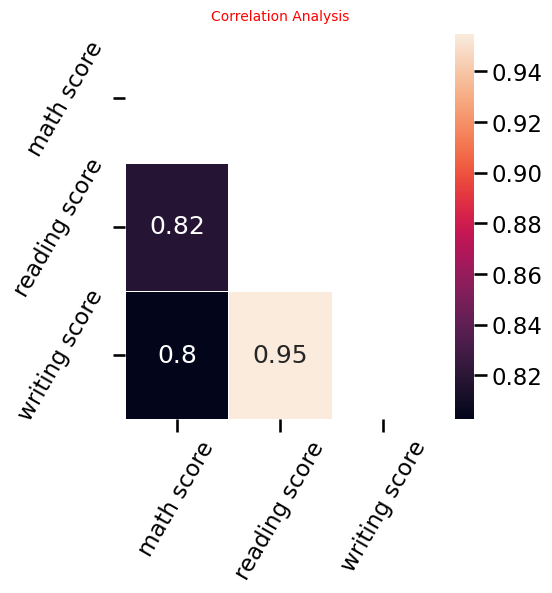

In [137]:
plt.figure(figsize=(5,5))
plt.title('Correlation Analysis',color='Red',fontsize=10,pad=10)

corr = df[['math score', 'reading score', 'writing score']].corr()
mask = np.triu(np.ones_like(corr,dtype = bool))
sns.heatmap(corr,mask=mask,annot=True,linewidths=.5);
plt.xticks(rotation=60)
plt.yticks(rotation = 60)
plt.show()

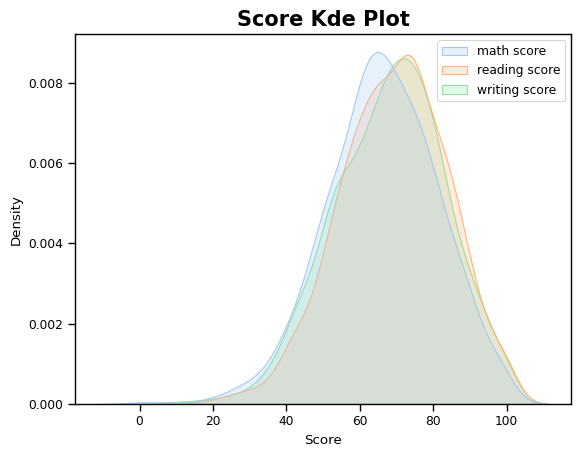

In [138]:
sns.set_context("paper",font_scale=1)
sns.kdeplot(data=df[['math score', 'reading score', 'writing score']],shade = True)
plt.xlabel('Score')
plt.title('Score Kde Plot', fontsize=15, fontweight='bold')
plt.show()

Text(1.0, 1.3, 'Reading and Mathematics score vs Gender')

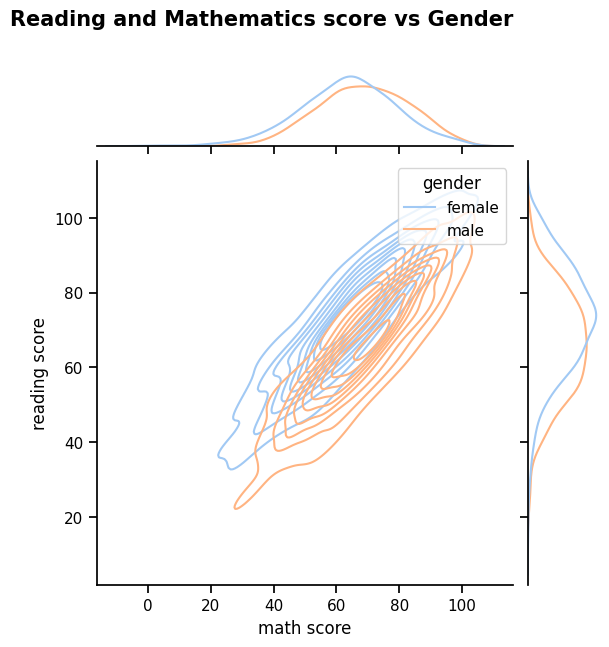

In [139]:

sns.set_context("notebook")
_= sns.jointplot(data=df, x="math score", y="reading score", hue="gender", kind="kde")
plt.title('Reading and Mathematics score vs Gender', fontsize=15, fontweight='bold',y=1.3,loc="right")


* We can see the relationship between reading and mathematical score and their gender distribution.

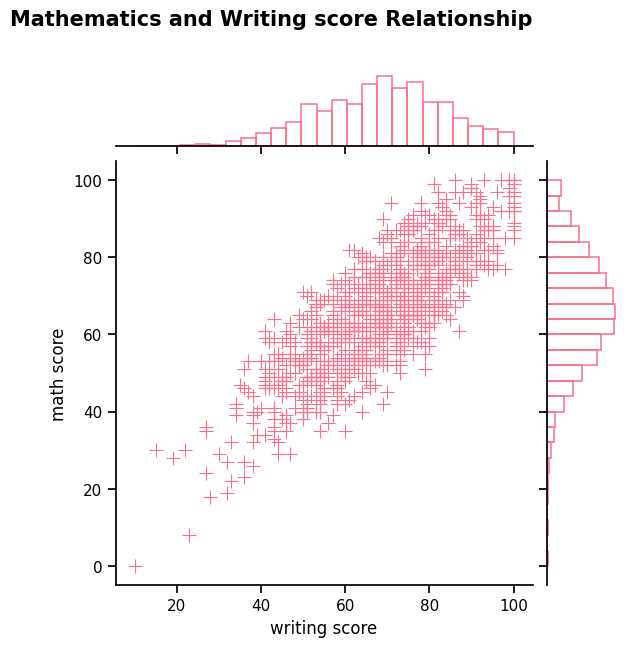

In [140]:
sns.set_palette("husl", 9)
sns.jointplot(
    data=df, x="writing score", y="math score",
    marker="+", s=100, marginal_kws=dict(bins=25, fill=False),
)
plt.title('Mathematics and Writing score Relationship', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

* Most students fall between the range of 40 to 85 marks in both the courses, mathematics and writing.

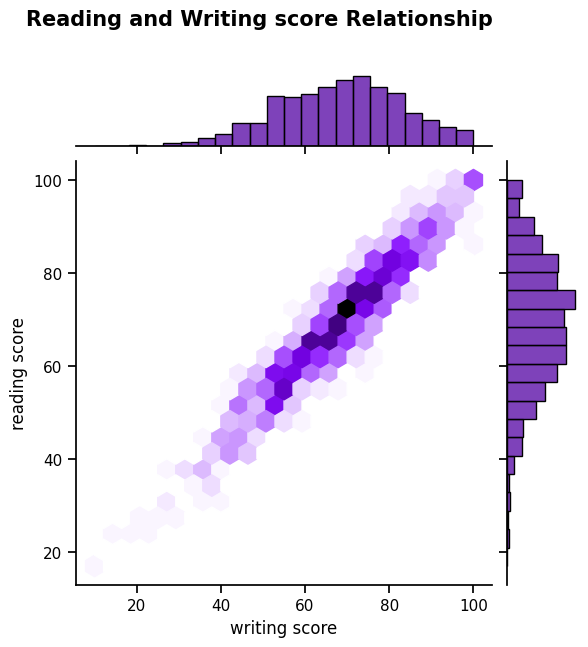

In [141]:
sns.set_palette("plasma")
sns.jointplot(data=df, x="writing score", y="reading score", kind="hex")
plt.title('Reading and Writing score Relationship', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

* The average score in both courses, reading and writing, is around 70.

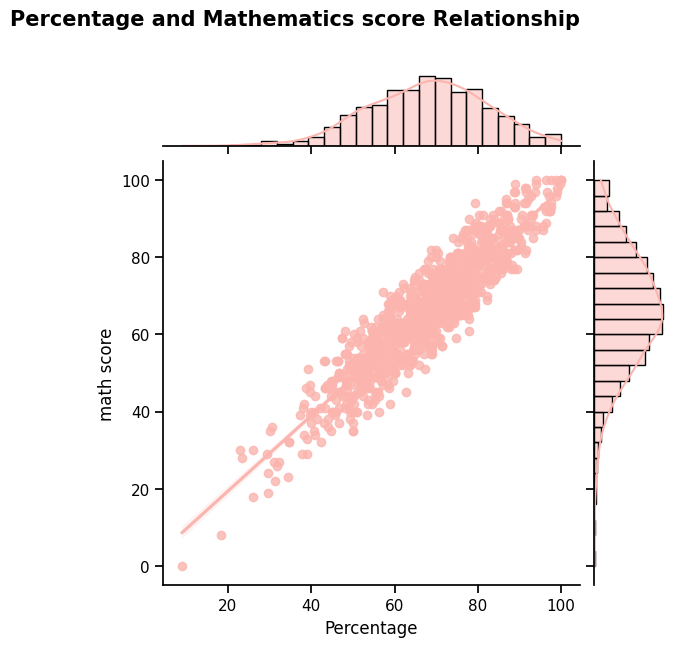

In [142]:
sns.set_palette("Pastel1")
sns.jointplot(data=df, x="Percentage", y="math score", kind="reg")
plt.title('Percentage and Mathematics score Relationship', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

* We can find that in the relationship between the percentage and the mathematics score, most student have scored in the range of 50 to 80. 

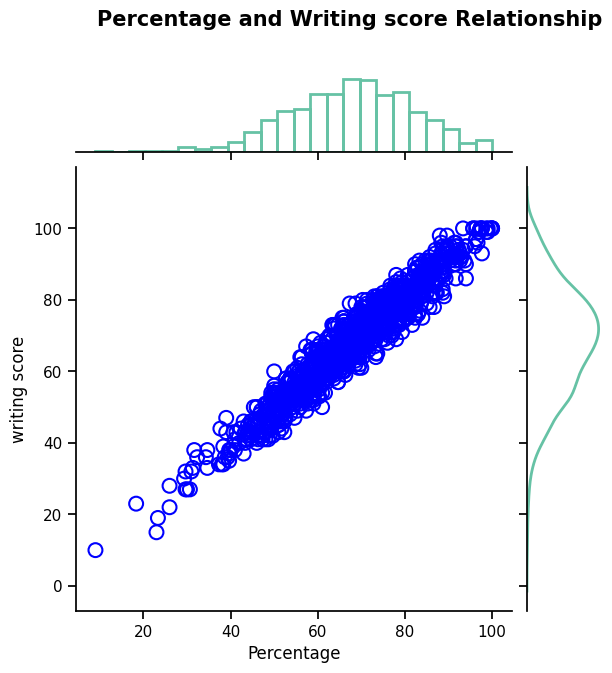

In [143]:
sns.set_palette("Set2")
g = sns.JointGrid()
x, y = df["Percentage"], df["writing score"]
sns.scatterplot(x=x, y=y, ec="b", fc="none", s=100, linewidth=1.5, ax=g.ax_joint)
sns.histplot(x=x, fill=False, linewidth=2, ax=g.ax_marg_x)
sns.kdeplot(y=y, linewidth=2, ax=g.ax_marg_y)
plt.title('Percentage and Writing score Relationship', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

* From the above visualization, we infer that most student have scored in the range of 60 to 80 which is constituting to the overall percentage as well.

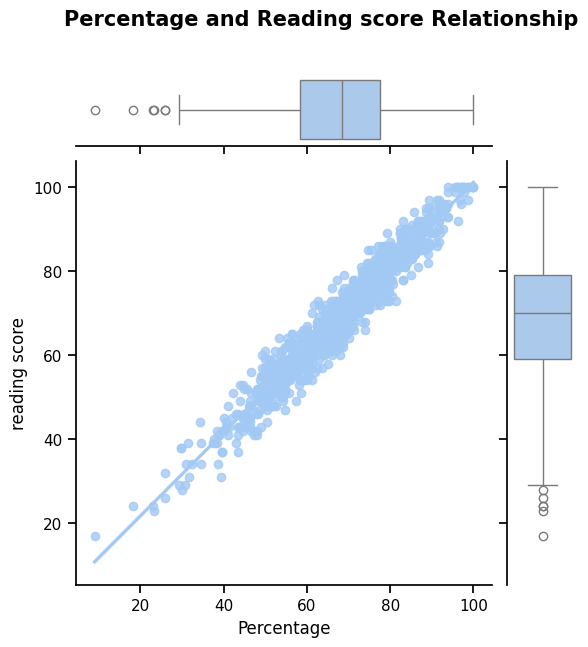

In [144]:
sns.set_context("notebook")
sns.set_palette("pastel")
g = sns.JointGrid(data=df, x="Percentage", y="reading score")
g.plot(sns.regplot, sns.boxplot)
plt.title('Percentage and Reading score Relationship', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()

* We can conclude that most students have a good reading score, except a few.

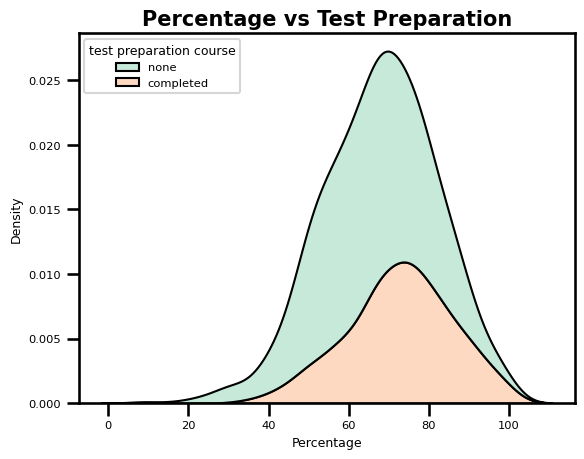

In [145]:
sns.set_context("talk",font_scale=0.5)
sns.set_palette("Pastel2")
sns.kdeplot(data=df, x="Percentage", hue="test preparation course", multiple="stack")
plt.title('Percentage vs Test Preparation',fontsize=15, fontweight='bold')

plt.show()

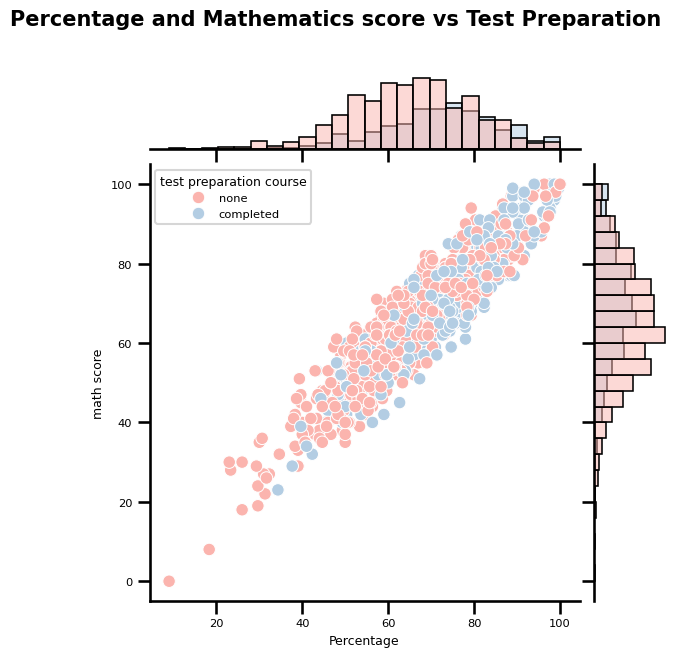

In [146]:
sns.set_palette("Pastel1")
g = sns.JointGrid(data=df, x="Percentage", y="math score", hue="test preparation course")
g.plot(sns.scatterplot, sns.histplot)
plt.title('Percentage and Mathematics score vs Test Preparation ', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()


From the above visualization we can infer that :
* Students who have completed their test preparations have definitely scored better. 
* While a few students who did not complete their test preparations have not performed so well.

* We can notice that there are few who have scored exceptionally good compared to others even when they did not complete their test perparation.

* Also, there are very few who completed their test preparation but still scored low percentage.

(We always have few exceptions.)

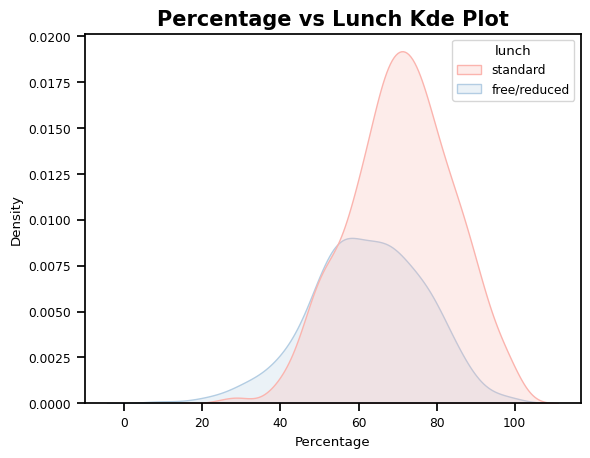

In [147]:
sns.set_context("notebook",font_scale=0.8)
sns.kdeplot(data=df, x="Percentage", hue="lunch", multiple="layer",fill=True)
plt.xlabel('Percentage')
plt.title('Percentage vs Lunch Kde Plot',fontsize=15, fontweight='bold')

plt.show()

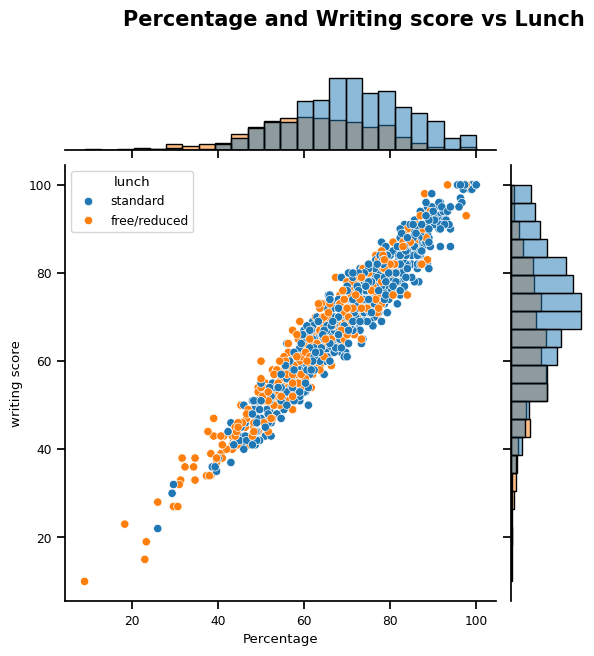

In [148]:
sns.set_palette("tab10")
g = sns.JointGrid(data=df, x="Percentage", y="writing score", hue="lunch")
g.plot(sns.scatterplot, sns.histplot)
plt.title('Percentage and Writing score vs Lunch', fontsize=15, fontweight='bold',y=1.3,loc="right")
plt.show()


Notice the range  75 to 100 in the above visualization.
* Students who had the standard lunch have performed very well.
* Students who had the free/reduced lunch have not performed so well.

It is very evident that food and nutriention play a vital role in the growth of a student both, physically and academically. Nutrition plays a key role in the healthy development of the children. Nutritious foods provide the body and mind with the energy needed to grow, feel well, be active, stay healthy and learn. Students are able to learn better when they're well nourished, and eating healthy meals has been linked to higher grades, better memory and alertness, and faster information processing.

Healthy students are better learners. 

In [149]:
df["grade"].value_counts()


grade
C    260
B    253
D    184
A    172
E     77
F     32
O     22
Name: count, dtype: int64

In [150]:
df["grade"].index.sort_values()

RangeIndex(start=0, stop=1000, step=1)

In [151]:
df[df['grade']=='F'].groupby('gender').count()


,Group,parental level of education,lunch,test preparation course,math score,reading score,writing score,Percentage,grade
gender,,,,,,,,,
female,17,17,17,17,17,17,17,17,17
male,15,15,15,15,15,15,15,15,15


In [152]:
df["Group"].value_counts()

Group
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

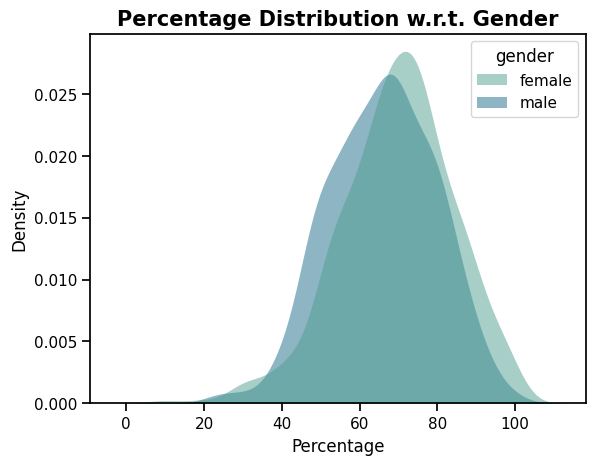

In [153]:
sns.set_context("notebook",font_scale=1)

sns.kdeplot(
   data=df, x="Percentage", hue="gender",
   fill=True, common_norm=False, palette="crest",
   alpha=.5, linewidth=0,
)
plt.title('Percentage Distribution w.r.t. Gender',fontsize=15, fontweight='bold')

plt.show()

* From the visualization above, it is quite evident that the female students have performed exceptionally well!

In [154]:
df.columns

Index(['gender', 'Group', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Percentage', 'grade'],
      dtype='object')

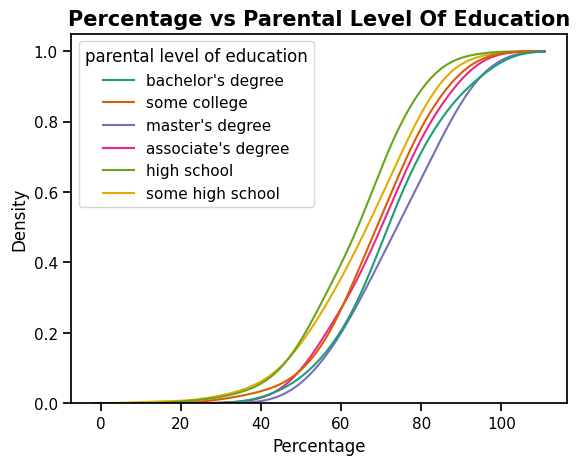

In [155]:
sns.set_palette("Dark2")
sns.set_context("notebook",font_scale=1)
sns.kdeplot(
    data=df, x="Percentage", hue="parental level of education",
    cumulative=True, common_norm=False, common_grid=True,
)
plt.title('Percentage vs Parental Level Of Education',fontsize=15, fontweight='bold')

plt.show()

* Students whose parents hold a master's degree have a higher overall percentage. 
* Students whose parental education level is 'high school' and 'some high school' have lower overall percentage.

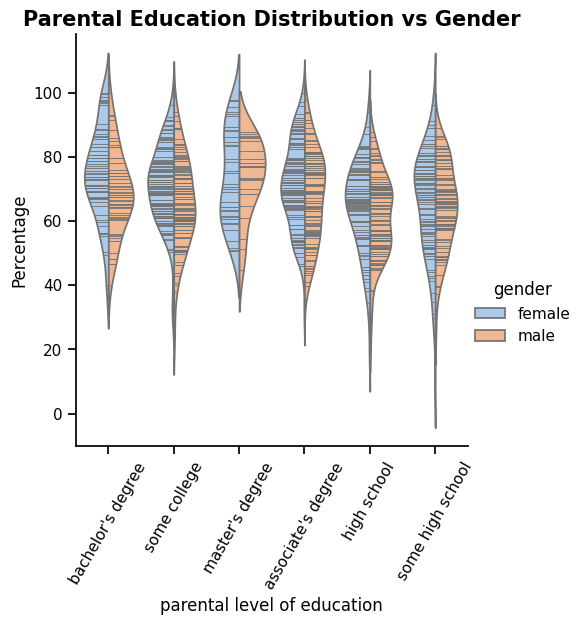

In [156]:

sns.catplot(x="parental level of education", y="Percentage", hue="gender",
            kind="violin", inner="stick", split=True,
            palette="pastel", data=df)
plt.title('Parental Education Distribution vs Gender',fontsize=15, fontweight='bold')
plt.xticks(rotation=60)
plt.show()

* Females whose parents hold a Bachelor's degree, followed by master's degree,are more successful.
* Males whose parents hold a Bachelor's degree and master's degree have similar academic performance

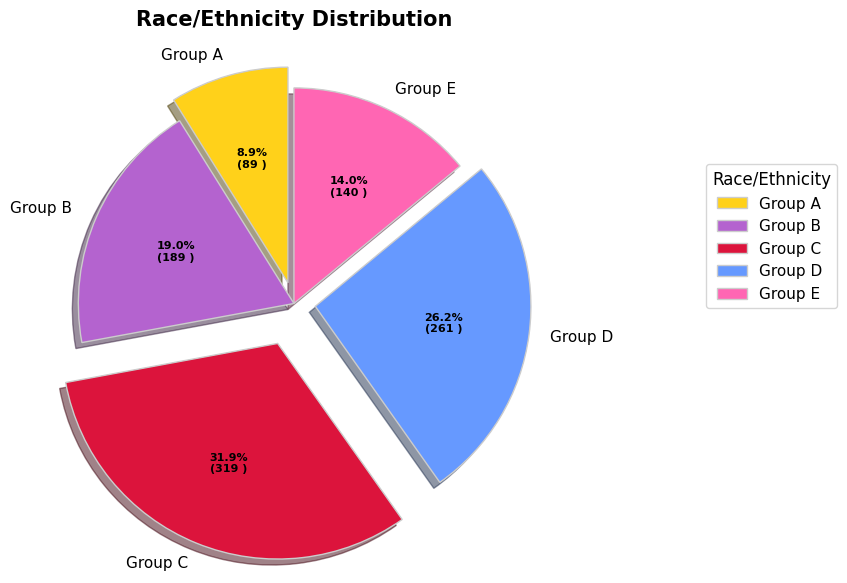

In [157]:
race = ['Group A', 'Group B ', 'Group C',  
        'Group D', 'Group E'] 
  
data = [89, 190, 319, 262, 140] 
  
  
# Creating explode data 
explode = ( 0.1, 0,0.2, 0.1, 0) 
  
# Creating color parameters 
colors = (  "#ffd11a", "#b463cf", 
          "#DC143C", "#6699ff", "#ff66b3" ) 
  
# Wedge properties 
wp = { 'linewidth' : 1, 'edgecolor' : "#cccccc" } 
  
# Creating autocpt arguments 
def func(pct, allvalues): 
    absolute = int(pct / 100.*np.sum(allvalues)) 
    return "{:.1f}%\n({:d} )".format(pct, absolute) 
  
# Creating plot 
fig, ax = plt.subplots(figsize =(10, 7)) 
wedges, texts, autotexts = ax.pie(data,  
                                  autopct = lambda pct: func(pct, data), 
                                  explode = explode,  
                                  labels = race, 
                                  shadow = True, 
                                  colors = colors, 
                                  startangle = 90, 
                                  wedgeprops = wp, 
                                  textprops = dict(color ="#000000")) 
  
# Adding legend 
ax.legend(wedges, race, 
          title ="Race/Ethnicity", 
          loc ="center left", 
          bbox_to_anchor =(1.25, 0, 0, 1.25)) 
  
plt.setp(autotexts, size = 8, weight ="bold") 
ax.set_title("Race/Ethnicity Distribution", fontsize=15, fontweight='bold') 
  
# show plot 
plt.show()

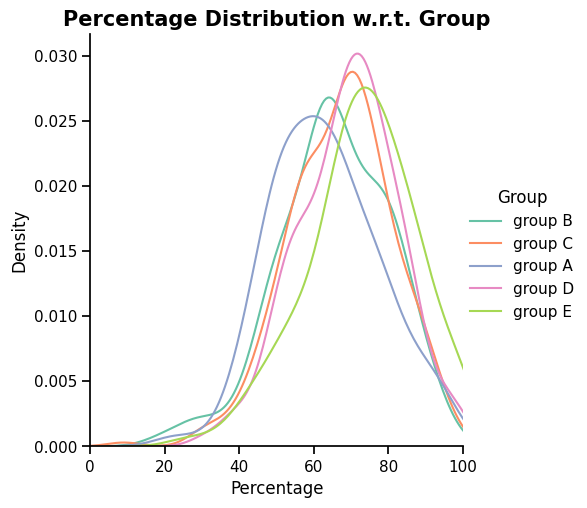

In [158]:
sns.set_palette("Set2")
(sns.FacetGrid(df,hue="Group", height=5,xlim = (0,100)).map(sns.kdeplot, "Percentage").add_legend())
plt.title('Percentage Distribution w.r.t. Group',fontsize=15, fontweight='bold')

plt.show()

* Performance of Group E is the best among all. While group D and C have nearly similar performance.

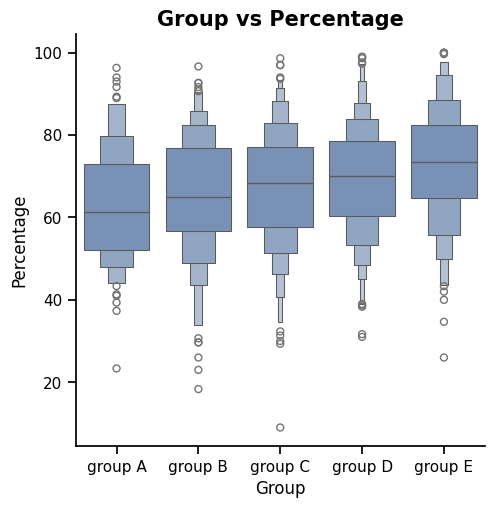

In [159]:
sns.set_palette("vlag")
sns.catplot(x="Group", y="Percentage", kind="boxen",
            data=df.sort_values("Group"))
plt.title('Group vs Percentage',fontsize=15, fontweight='bold')

plt.show()

* The average of group E is highest among all the groups while the average of group A is lowest.

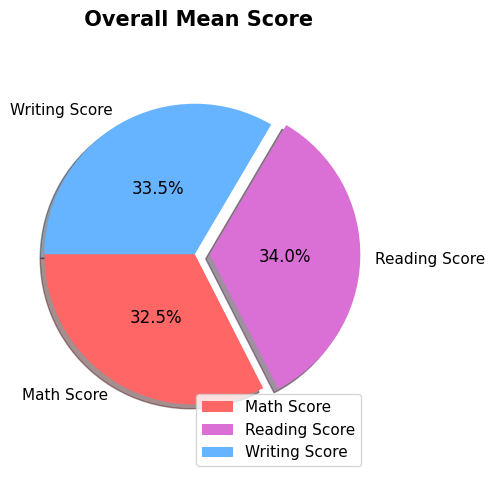

In [160]:
plt.figure(figsize=(5,5))
labels=['Math Score', 'Reading Score', 'Writing Score']
colors=['#ff6666','orchid','#66b3ff']
explode=[0,0.1,0]
values=[df["math score"].mean(),df["reading score"].mean(),df["writing score"].mean()]

plt.pie(values,labels=labels,colors=colors,explode=explode,autopct='%1.1f%%',shadow=True,startangle=180,pctdistance=0.5)
plt.legend(['Math Score', 'Reading Score', 'Writing Score'],loc='lower right')
plt.axis('equal')
plt.title(' Overall Mean Score  ',fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

* Reading Score has the highest average.

In [161]:
df.sample(3)

,gender,Group,parental level of education,lunch,test preparation course,math score,reading score,writing score,Percentage,grade
596,male,group B,high school,free/reduced,none,30,24,15,23.000000,F
785,female,group B,some high school,standard,completed,32,51,44,42.333333,E
554,male,group E,associate's degree,standard,none,53,45,40,46.000000,E


In [162]:
df["parental level of education"].mode()[0]

'some college'

In [163]:
df["parental level of education"].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [164]:
df["parental level of education"].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

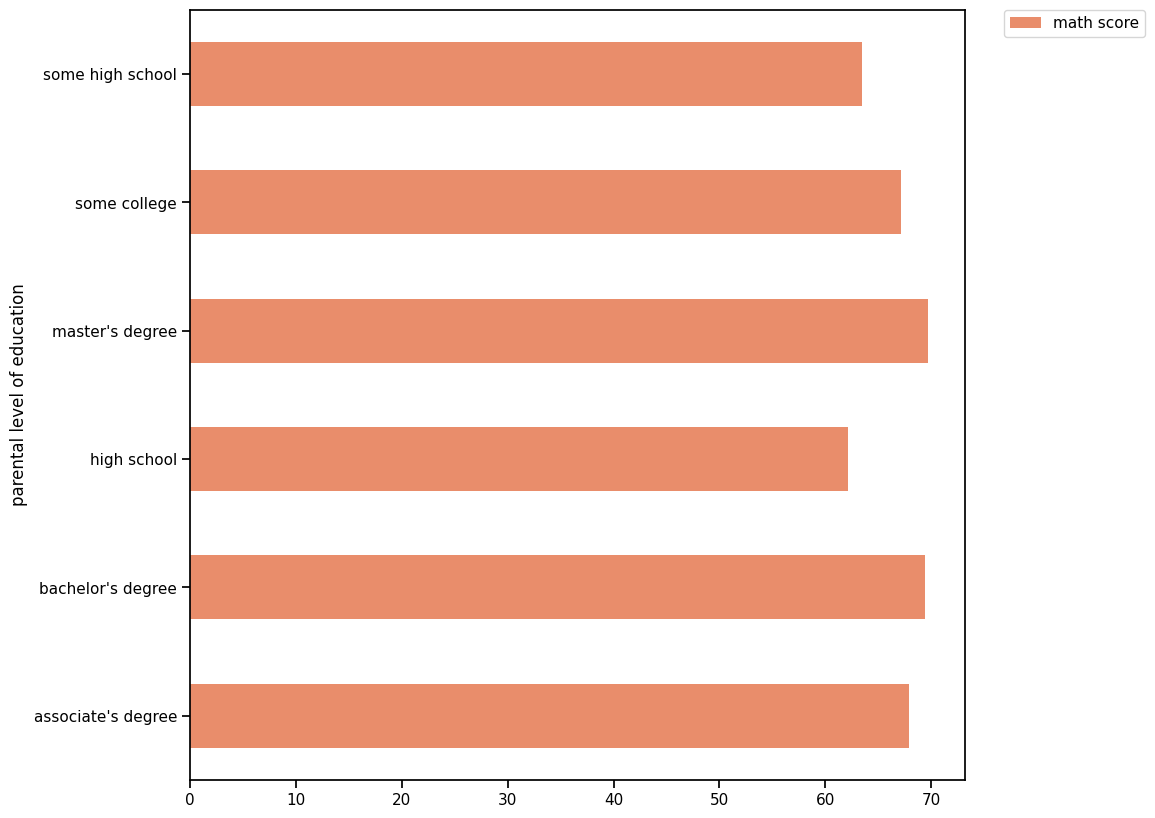

In [165]:
sns.set_palette("flare")
df.groupby('parental level of education')["math score"].agg('mean').plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.);

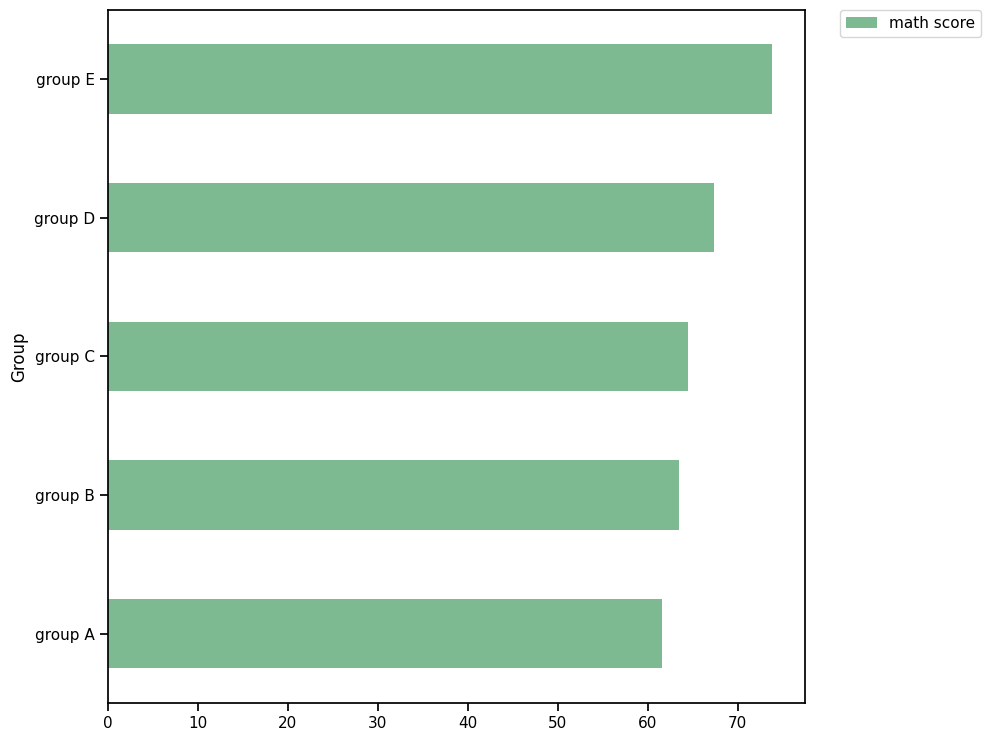

In [166]:
sns.set_palette("crest")
df.groupby('Group')["math score"].agg('mean').plot(kind='barh',figsize=(9,9))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.);

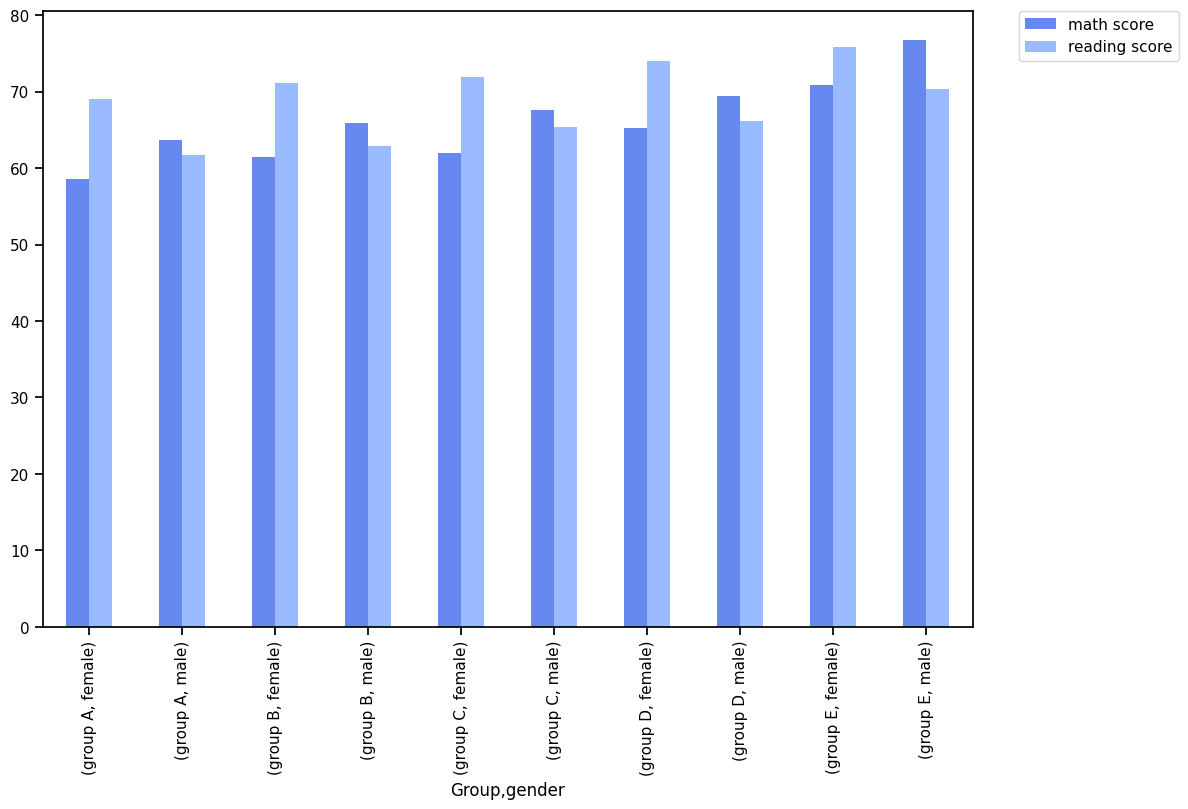

In [167]:
sns.set_palette("coolwarm")
df.groupby(['Group','gender'])[["math score",	"reading score"]].agg('mean').plot(kind='bar',figsize=(12,8))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.);

In [169]:
# Illiminate  outlier out of the datset
from scipy import stats
num_features= df.select_dtypes(include="number").columns
# Filter rows where all numeric features have z-scores less than 3
df = df[(np.abs(stats.zscore(df[num_features])) < 3).all(axis=1)]


In [170]:
df.head()

,gender,Group,parental level of education,lunch,test preparation course,math score,reading score,writing score,Percentage,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,B
1,female,group C,some college,standard,completed,69,90,88,82.333333,A
2,female,group B,master's degree,standard,none,90,95,93,92.666667,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,E
4,male,group C,some college,standard,none,76,78,75,76.333333,B


In [171]:
# data normalization 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[num_features] = scaler.fit_transform(df[num_features])
df[num_features].head(10)

,math score,reading score,writing score,Percentage
0,0.641026,0.611111,0.643836,0.613208
1,0.602564,0.861111,0.835616,0.750000
2,0.871795,0.930556,0.904110,0.896226
3,0.320513,0.402778,0.232877,0.283019
4,0.692308,0.694444,0.657534,0.665094
5,0.628205,0.763889,0.698630,0.679245
6,0.846154,0.930556,0.890411,0.882075
7,0.230769,0.208333,0.164384,0.160377
8,0.538462,0.500000,0.547945,0.504717
9,0.205128,0.444444,0.315068,0.283019


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 993 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   gender                       993 non-null    object  
 1   Group                        993 non-null    object  
 2   parental level of education  993 non-null    object  
 3   lunch                        993 non-null    object  
 4   test preparation course      993 non-null    object  
 5   math score                   993 non-null    float64 
 6   reading score                993 non-null    float64 
 7   writing score                993 non-null    float64 
 8   Percentage                   993 non-null    float64 
 9   grade                        993 non-null    category
dtypes: category(1), float64(4), object(5)
memory usage: 78.9+ KB


In [173]:
df.select_dtypes(exclude="number").columns

Index(['gender', 'Group', 'parental level of education', 'lunch',
       'test preparation course', 'grade'],
      dtype='object')

In [ ]:
# df = pd.get_dummies(df, columns=cat_features, drop_first=True)

In [174]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Select categorical features
cat_features = df.select_dtypes(include=["object", "category"]).columns

# Create an instance of OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the categorical features
encoded_data = encoder.fit_transform(df[cat_features])

# Convert the encoded data to a DataFrame
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_features))

In [175]:
# Drop original categorical columns and concatenate the encoded DataFrame
df = pd.concat([df.drop(columns=cat_features), encoded_df], axis=1)

# Display the updated DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 980
Data columns (total 22 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   math score                                     993 non-null    float64
 1   reading score                                  993 non-null    float64
 2   writing score                                  993 non-null    float64
 3   Percentage                                     993 non-null    float64
 4   gender_male                                    993 non-null    float64
 5   Group_group B                                  993 non-null    float64
 6   Group_group C                                  993 non-null    float64
 7   Group_group D                                  993 non-null    float64
 8   Group_group E                                  993 non-null    float64
 9   parental level of education_bachelor's degree  993 non-nul

In [176]:
df.head()

,math score,reading score,writing score,Percentage,gender_male,Group_group B,Group_group C,Group_group D,Group_group E,parental level of education_bachelor's degree,...,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none,grade_B,grade_C,grade_D,grade_E,grade_F,grade_O
0,0.641026,0.611111,0.643836,0.613208,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.602564,0.861111,0.835616,0.750000,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.871795,0.930556,0.904110,0.896226,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.320513,0.402778,0.232877,0.283019,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.692308,0.694444,0.657534,0.665094,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
